# 90-Minute Exercise

Vi vil nu gennemgå hjertet, med det udgangspunkt at det er en pumpe.
Vi starter med at skulle beskrive hjertets opbygning.

1.  **Beskriv hjertets strukturer og blodets vej gennem hjertet.**
    *   Angiv rækkefølgen af kamre og klapper, som blodet passerer igennem, fra det kommer tilbage fra kroppen til det forlader hjertet mod systemisk kredsløb.

2.  **Forklar, hvordan hjertets minutvolumen (cardiac output) relaterer sig til strokevolume og heartrate/puls.**
    *   Inkludér formlen og hvilke parametre der indgår.

3.  **Diskutér sammenhængen mellem trykforhold og dilateret kardiomyopati.**
    *   Hvordan påvirker en dilateret venstre ventrikel tryk og volumenforhold i hjertet og kredsløbet? 
    *   Hvorfor vil en dilateret venstre ventrikel også fører til hyperthrophy?


***



### **Svarvejledning**

*   **Blodets vej:**  
    Vena cava → højre atrium → trikuspidalklap → højre ventrikel → pulmonalklap → lungearterie → lunger → lungevener → venstre atrium → mitralklap → venstre ventrikel → aortaklap → aorta.

*   **Cardiac Output (CO):**
    $ CO = HR  \cdot SV $  
    hvor HR = hjertefrekvens (slag/min) og SV = slagvolumen (ml/slag).

*   **Dilateret kardiomyopati:**
    *   Øget ventrikelvolumen → nedsat kontraktilitet → lavere slagvolumen → kompensatorisk stigning i HR.
    *   Trykforhold: Venstre ventrikel dilaterer → øget slutdiastolisk volumen → øget preload, men nedsat effektivt trykudvikling → lavt arterielt tryk og øget venøst tryk → risiko for lungeødem.




### **Øvelse: Beregn vægspænding i venstre ventrikel**

**Baggrund:**  
Laplaces lov for en kugleformet struktur kan skrives som:
$$
P = \frac{2 \cdot \sigma \cdot w}{r}
$$
hvor:
*   ($P$) = indre tryk (mmHg)
*   ($\sigma$) = vægspænding (N/m²)
*   ($w$) = vægtykkelse (m)
*   ($r$) = indre radius (m)

**Opgave:**
1.  Antag at venstre ventrikel har:
    *   Radius ($r = 3 \text{ cm}$)
    *   Vægtykkelse ($w = 1 \text{ cm}$)
    *   Tryk (P$ = 120 \text{ mmHg}$) (konverter til Pascal: ($1 \text{ mmHg} \approx 133.3 \text{ Pa})$)
2.  Beregn vægspændingen ($\sigma$) i en funktion.
3.  Diskutér, hvordan vægspændingen ændres ved dilateret kardiomyopati (øget radius, reduceret vægtykkelse).



**Beregn wall stress for en hjertecyklus**

Benyt den laplacian funktion du har lavet ovenover til at plotte wall tension gennem in hjertecyklus


In [ ]:
# Load data
import pandas as pd
df = pd.read_csv("files/heart_pressures.csv")
df

,Phase,time,P_LV,P_AO,V_LV,stress_AO
0,End-diastole (filling),0.00,10,80,120,33
1,Atrial contraction,0.10,15,80,130,33
2,Isovolumetric contraction,0.13,30,80,130,33
3,Early ejection,0.16,80,85,100,35
4,Peak systole,0.30,120,120,70,49
5,Late ejection,0.40,100,115,60,47
6,Isovolumetric relaxation,0.50,60,100,60,41
7,Early diastole,0.55,20,90,80,37
8,Mid-diastole,0.70,10,85,100,35
9,End-diastole (next cycle),1.00,10,80,120,33


In [ ]:
import math

def laplace_sigma(P, r, thickness, Pext=0.0):
    """Thin-walled Laplace law: sigma = (P_tm * r) / (2h)."""
    Ptm = (P - Pext)
    wallstress = Ptm * r  / 2.0 / thickness
    return wallstress


def radius_from_volume_ml(volume_ml):
    # Volume in mL is equivalent to cm³
    r = ((3 * volume_ml) / (4 * math.pi)) ** (1/3) * 10
    return r


In [42]:
df["R_LV"] = df["V_LV"].map(radius_from_volume_ml)
df["stress_LV"] = df.apply(lambda row: laplace_sigma(P=row["P_LV"],r=row["R_LV"],thickness=12.5), axis=1)

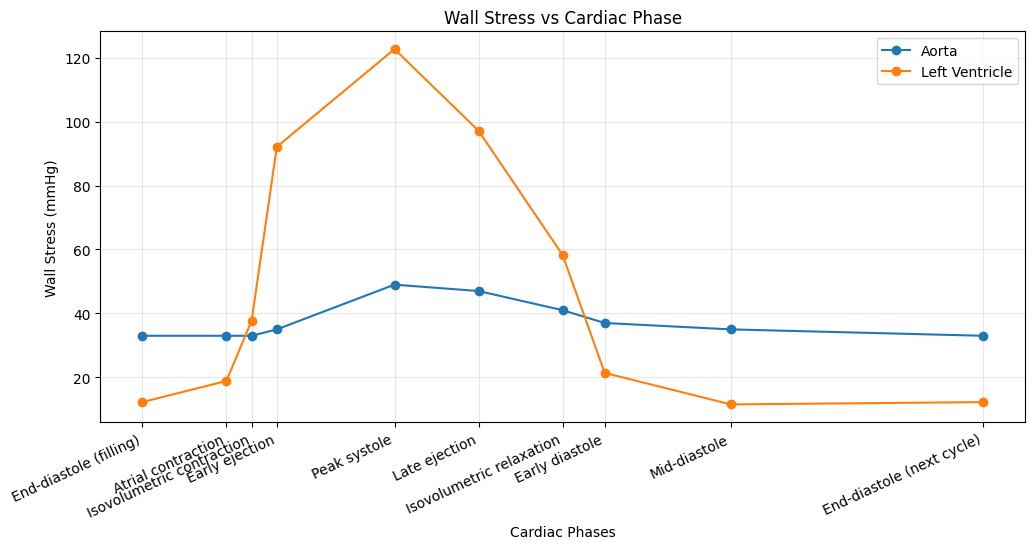

In [45]:
import matplotlib.pyplot as plt


plt.figure(figsize=(10.5, 5.6))
plt.plot(df['time'], df['stress_AO'], marker='o', label="Aorta")
plt.plot(df['time'], df['stress_LV'], marker='o', label="Left Ventricle")
plt.title('Wall Stress vs Cardiac Phase')
plt.xlabel('Cardiac Phases')
plt.ylabel('Wall Stress (mmHg)')
plt.grid(alpha=0.3)
plt.xticks(ticks=df['time'],labels=df['Phase'].to_list(), rotation=25, ha='right')
plt.tight_layout()
plt.legend()
plt.show()
